<a href="https://colab.research.google.com/github/AnkushSharmaGuragai/AI-ML/blob/main/haha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""PDA.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/10Lrz_IdKhOXawKkZAWdptusOU-ZSyET2
"""

from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# =========================
# UNZIP DATASET
# =========================
zip_path = "/content/drive/MyDrive/AI ML/face.zip"
extract_path = "/content/drive/MyDrive/AI ML/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP extracted successfully.


         Split     Class  Count
0        Train     angry   3693
1        Train   disgust    336
2        Train      fear   3803
3        Train     happy   6864
4        Train   neutral   4682
5        Train       sad   4638
6        Train  surprise   2905
7   Validation     angry    960
8   Validation   disgust    111
9   Validation      fear   1018
10  Validation     happy   1825
11  Validation   neutral   1216
12  Validation       sad   1139
13  Validation  surprise    797
14        Test     angry    300
15        Test   disgust    100
16        Test      fear    300
17        Test     happy    300
18        Test   neutral    300
19        Test       sad    300
20        Test  surprise    300

Class Distribution:
 Split     Test  Train  Validation
Class                            
angry      300   3693         960
disgust    100    336         111
fear       300   3803        1018
happy      300   6864        1825
neutral    300   4682        1216
sad        300   4638        1139
su

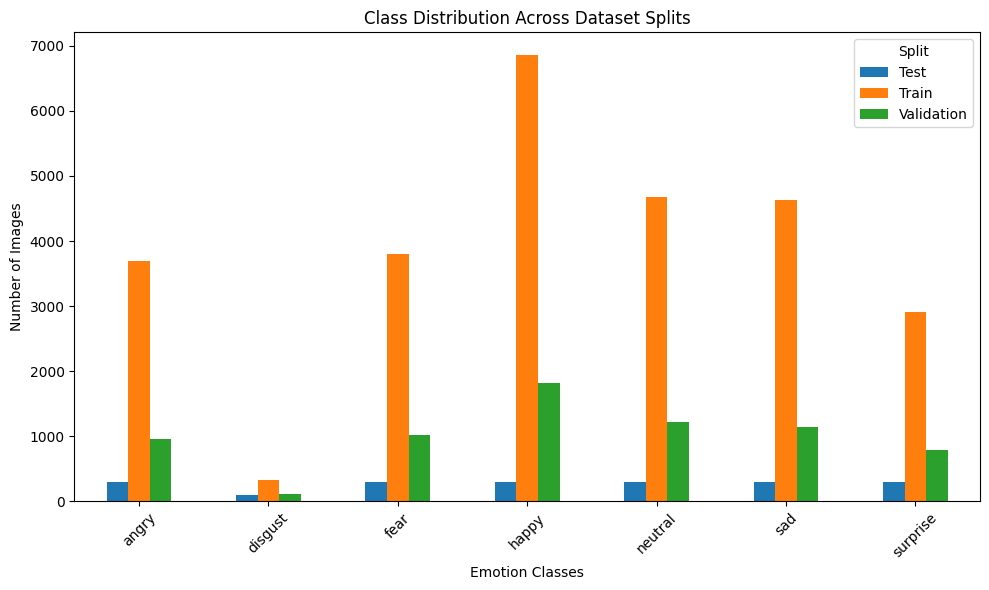

Percentage Distribution of Each Class:

Split      Test  Train  Validation
Class                             
angry     15.79  13.72       13.59
disgust    5.26   1.25        1.57
fear      15.79  14.13       14.41
happy     15.79  25.50       25.83
neutral   15.79  17.39       17.21
sad       15.79  17.23       16.12
surprise  15.79  10.79       11.28


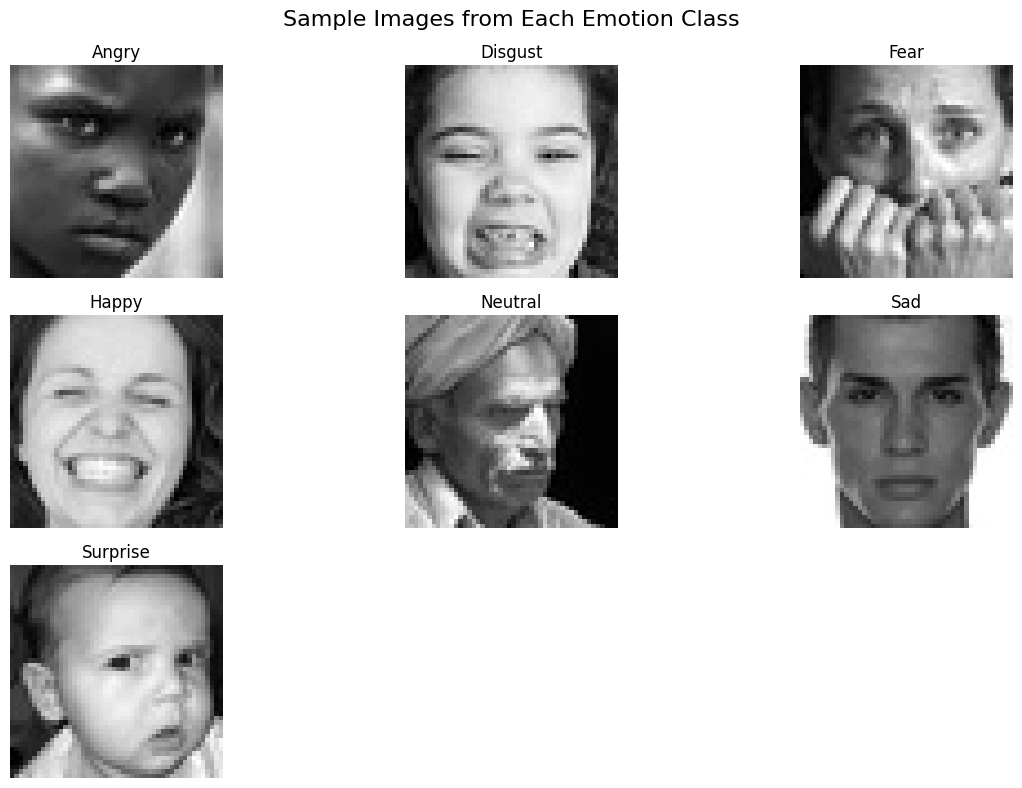

Image Size: (48, 48)
Image Mode: L
Total Images: 35887
Training Images: 26921
Validation Images: 7066
Testing Images: 1900
Unique Image Sizes: {(48, 48)}
Unique Image Modes: {'L'}
Minimum Pixel Value in Dataset: 0
Maximum Pixel Value in Dataset: 255
Total Corrupted Images Found: 0
No corrupted images found.

 Total Deleted: 0
Total Duplicate File Names Found: 0
No duplicate file names found within each split.
Using image: /content/drive/MyDrive/AI ML/facial_expression/images/train/angry/15569.jpg
Before Normalization:
Min Pixel Value: 4
Max Pixel Value: 245

After Normalization:
Min Pixel Value: 0.01568627450980392
Max Pixel Value: 0.9607843137254902


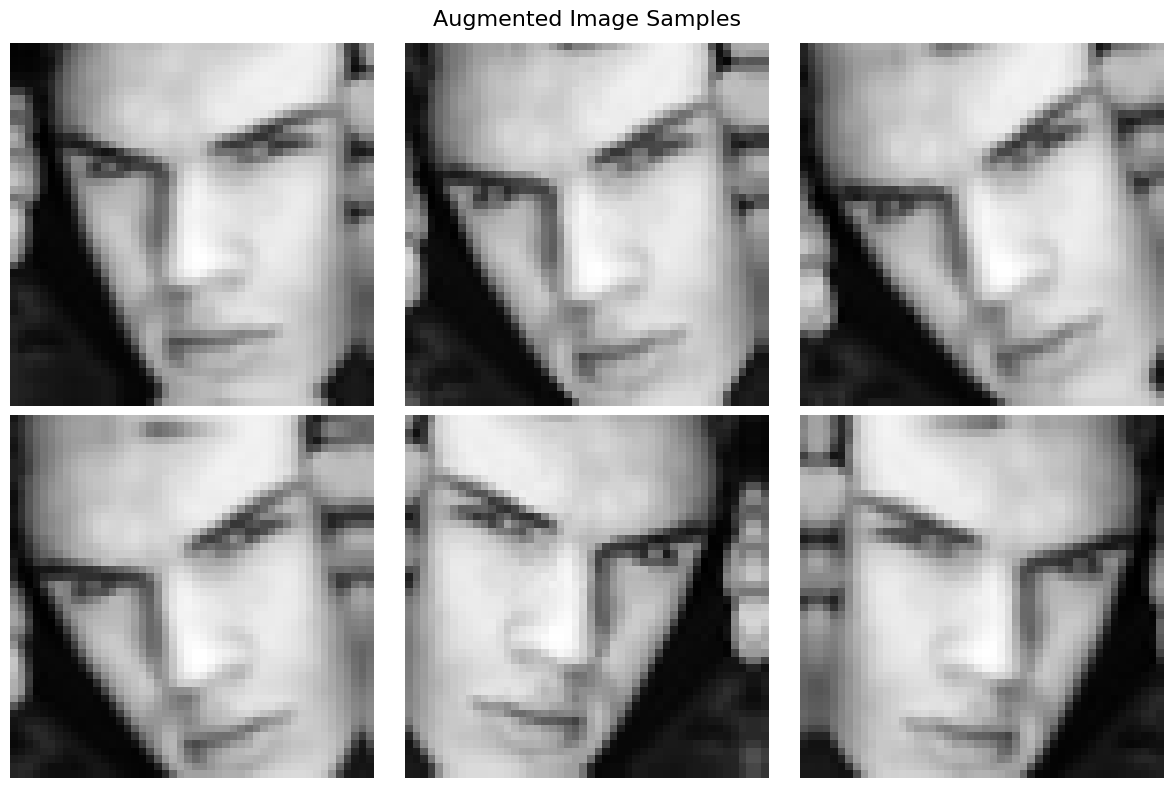

In [14]:


train_dir = "/content/drive/MyDrive/AI ML/facial_expression/images/train"
test_dir = "/content/drive/MyDrive/AI ML/facial_expression/images/test"
validation_dir = "/content/drive/MyDrive/AI ML/facial_expression/images/validation"

"""Analyze Class Distribution"""

def count_images(directory, split_name):
    data = []
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            data.append({
                "Split": split_name,
                "Class": class_name,
                "Count": num_images
            })
    return data

# Collect data from all splits
data = []
data.extend(count_images(train_dir, "Train"))
data.extend(count_images(validation_dir, "Validation"))
data.extend(count_images(test_dir, "Test"))

df = pd.DataFrame(data)
print(df)

# Pivot table for better visualization
pivot_df = df.pivot(index="Class", columns="Split", values="Count").fillna(0)
print("\nClass Distribution:\n", pivot_df)

pivot_df.plot(kind='bar', figsize=(10,6))
plt.title('Class Distribution Across Dataset Splits')
plt.xlabel('Emotion Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

percentage_df = pivot_df.div(pivot_df.sum(axis=0), axis=1) * 100
percentage_df = percentage_df.round(2)

print("Percentage Distribution of Each Class:\n")
print(percentage_df)

"""Visualize Sample Images"""

classes = sorted([
    class_name for class_name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, class_name))
])

plt.figure(figsize=(12, 8))
for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(class_name.capitalize())
    plt.axis('off')

plt.suptitle('Sample Images from Each Emotion Class', fontsize=16)
plt.tight_layout()
plt.show()

"""Check Image Properties (Size and Color Channels)"""

sample_class = classes[0]
sample_image_path = os.path.join(
    train_dir,
    sample_class,
    os.listdir(os.path.join(train_dir, sample_class))[0]
)

img = Image.open(sample_image_path)
print("Image Size:", img.size)
print("Image Mode:", img.mode)

"""Dataset Summary Statistics"""

total_images = df['Count'].sum()
train_images = df[df['Split'] == 'Train']['Count'].sum()
validation_images = df[df['Split'] == 'Validation']['Count'].sum()
test_images = df[df['Split'] == 'Test']['Count'].sum()

print(f"Total Images: {total_images}")
print(f"Training Images: {train_images}")
print(f"Validation Images: {validation_images}")
print(f"Testing Images: {test_images}")

"""Detailed Image Properties Analysis"""

image_sizes = []
image_modes = []
pixel_mins = []
pixel_maxs = []

for split_dir, split_name in [(train_dir, "Train"), (validation_dir, "Validation"), (test_dir, "Test")]:
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    img_array = np.array(img)

                    image_sizes.append(img.size)
                    image_modes.append(img.mode)
                    pixel_mins.append(img_array.min())
                    pixel_maxs.append(img_array.max())
                except:
                    pass

print("Unique Image Sizes:", set(image_sizes))
print("Unique Image Modes:", set(image_modes))
print("Minimum Pixel Value in Dataset:", min(pixel_mins))
print("Maximum Pixel Value in Dataset:", max(pixel_maxs))

"""Check for Corrupted Images"""

corrupted_images = []

for split_dir, split_name in [(train_dir, "Train"), (validation_dir, "Validation"), (test_dir, "Test")]:
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    img.verify()
                except Exception as e:
                    corrupted_images.append((split_name, class_name, img_name, str(e)))

print("Total Corrupted Images Found:", len(corrupted_images))

if len(corrupted_images) > 0:
    for item in corrupted_images[:10]:
        print(item)
else:
    print("No corrupted images found.")

"""Delete Corrupted Images"""

removed_count = 0

for split_name, class_name, img_name, error in corrupted_images:

    if split_name == "Train":
        base_dir = train_dir
    elif split_name == "Validation":
        base_dir = validation_dir
    else:
        base_dir = test_dir

    img_path = os.path.join(base_dir, class_name, img_name)

    try:
        os.remove(img_path)
        print("Deleted:", img_path)
        removed_count += 1
    except Exception as e:
        print("Error deleting:", img_path, e)

print("\n Total Deleted:", removed_count)

"""Check for Duplicate File Names"""

duplicate_files = []

for split_dir, split_name in [(train_dir, "Train"), (validation_dir, "Validation"), (test_dir, "Test")]:
    seen_files = set()
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name in seen_files:
                    duplicate_files.append((split_name, img_name))
                else:
                    seen_files.add(img_name)

print("Total Duplicate File Names Found:", len(duplicate_files))
if len(duplicate_files) > 0:
    print(duplicate_files[:10])
else:
    print("No duplicate file names found within each split.")

"""Normalization Example"""

sample_img_path = None

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
                img = Image.open(img_path)
                sample_img_path = img_path
                break
            except:
                continue
        if sample_img_path is not None:
            break

if sample_img_path is None:
    print("No valid image found.")
else:
    img = Image.open(sample_img_path)
    img_array = np.array(img)

    print("Using image:", sample_img_path)
    print("Before Normalization:")
    print("Min Pixel Value:", img_array.min())
    print("Max Pixel Value:", img_array.max())

    img_normalized = img_array / 255.0

    print("\nAfter Normalization:")
    print("Min Pixel Value:", img_normalized.min())
    print("Max Pixel Value:", img_normalized.max())

"""Data Augmentation Example"""

import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    # tf.keras.layers.RandomZoom(0.03),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

safe_image_path = None

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                temp_img = Image.open(img_path)
                temp_img.verify()

                safe_image_path = img_path
                break
            except:
                continue
        if safe_image_path is not None:
            break

if safe_image_path is None:
    print("No valid image found for augmentation.")
else:
    img = Image.open(safe_image_path).convert("L")
    img = img.resize((48, 48))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=-1)
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(12, 8))
    for i in range(6):
        augmented_img = data_augmentation(img_array, training=True)
        plt.subplot(2, 3, i + 1)
        plt.imshow(tf.squeeze(augmented_img), cmap='gray')
        plt.axis('off')

    plt.suptitle("Augmented Image Samples", fontsize=16)
    plt.tight_layout()
    plt.show()